### 1. LIBRARIES

In [3]:
import pandas as pd #data analysis
import numpy as np #numerical computations
import matplotlib.pyplot as plt #data visualisations
import seaborn as sns #advanced data visualisations

### 2. DATA LOADING AND VISUAL STYLE

In [4]:
df = pd.read_csv("bank-full.csv", sep = ";") #storing the data into a dataframe (df)
sns.set(style = "whitegrid") #setting visual style for cleaner plots
df.head() #displaying the data (first 5 rows)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### 3. DATA AUDIT (INITIAL DATA INSPECTION)

In [5]:
#checking shape of dataset (rows, columns)
print("Dataset shape:", df.shape)

#checking column names and data types
print("\nData types:")
print(df.dtypes)

#checking for missing values
print("\nMissing values:")
print(df.isnull().sum())

#checking for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

#summary statistics for numerical columns
print("\nSummary statistics:")
print(df.describe())

Dataset shape: (45211, 17)

Data types:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate rows: 0

Summary statistics:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.52

### 4. DATA CLEANING AND FORMATTING

In [7]:
#removing duplicate rows (safety step)
df = df.drop_duplicates()

#converting target variable "y" to binary (1 = converted, 0 = not converted)
df["converted"] = df["y"].map({"yes": 1, "no": 0})

#converting categorical "yes/no" columns into binary
binary_cols = ["default", "housing", "loan"]

for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

#converting duration to numeric just in case (should already be correct)
df["duration"] = pd.to_numeric(df["duration"], errors = "coerce")

#final check
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,converted
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0,unknown,no,0


### 5. FUNNEL CONSTRUCTION

In [8]:
#total users (everyone in dataset)
total_users = len(df)

#stage 1: contacted clients (exclude "unknown")
contacted = df[df["contact"] != "unknown"]
contacted_count = len(contacted)

#stage 2: engaged clients (call duration > 0)
engaged = contacted[contacted["duration"] > 0]
engaged_count = len(engaged)

#stage 3: converted clients
converted = engaged[engaged["converted"] == 1]
converted_count = len(converted)

#storing funnel values in dictionary
funnel = {
    "Total Users": total_users,
    "Contacted": contacted_count,
    "Engaged": engaged_count,
    "Converted": converted_count
}

#converting to DataFrame for easier visualization
funnel_df = pd.DataFrame(list(funnel.items()), columns = ["Stage", "Users"])

funnel_df

,Stage,Users
0,Total Users,45211
1,Contacted,32191
2,Engaged,32189
3,Converted,4759


### 6. CONVERSION RATES

In [9]:
#Conversion metrics
contact_rate = contacted_count / total_users
engagement_rate = engaged_count / contacted_count
conversion_rate = converted_count / engaged_count
overall_conversion = converted_count / total_users

#printing results
print(f"Contact Rate: {contact_rate:.2%}")
print(f"Engagement Rate: {engagement_rate:.2%}")
print(f"Conversion Rate (Engaged → Converted): {conversion_rate:.2%}")
print(f"Overall Conversion Rate: {overall_conversion:.2%}")

Contact Rate: 71.20%
Engagement Rate: 99.99%
Conversion Rate (Engaged → Converted): 14.78%
Overall Conversion Rate: 10.53%


### 7. FUNNEL VISUALIZATION

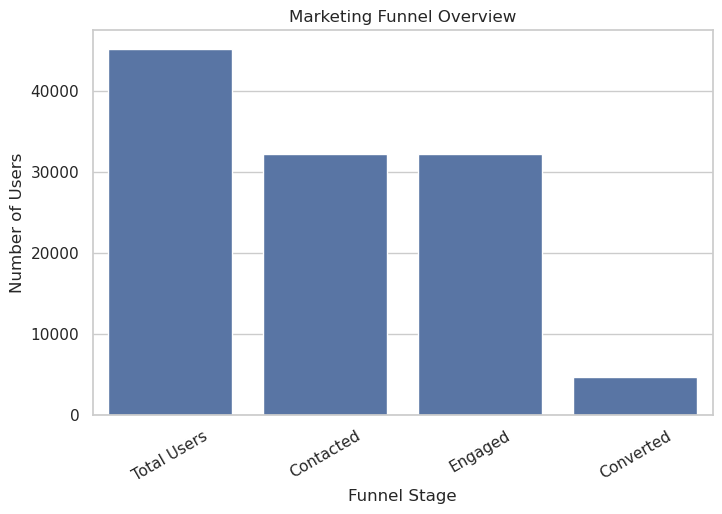

In [10]:
#plotting funnel stages
plt.figure(figsize = (8, 5))

sns.barplot(x = "Stage", y = "Users", data = funnel_df)

#adding title and labels
plt.title("Marketing Funnel Overview")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")

#rotating labels for clarity
plt.xticks(rotation = 30)

plt.show()

### 8. DROP-OFF RATES (ANALYSIS)

In [11]:
#calculating drop-offs between stages
drop_contact = total_users - contacted_count
drop_engaged = contacted_count - engaged_count
drop_converted = engaged_count - converted_count

drop_data = {
    "Stage": ["Not Contacted", "Not Engaged", "Not Converted"],
    "Users Lost": [drop_contact, drop_engaged, drop_converted]
}

drop_df = pd.DataFrame(drop_data)

drop_df

,Stage,Users Lost
0,Not Contacted,13020
1,Not Engaged,2
2,Not Converted,27430


### 9. CHANNEL PERFORMANCE

In [12]:
#Conversion rate by contact method
channel_perf = df.groupby("contact")["converted"].mean().sort_values(ascending = False)

channel_perf

contact
cellular     0.149189
telephone    0.134205
unknown      0.040707
Name: converted, dtype: float64

### 10. CAMPAIGN EFFECTIVENESS

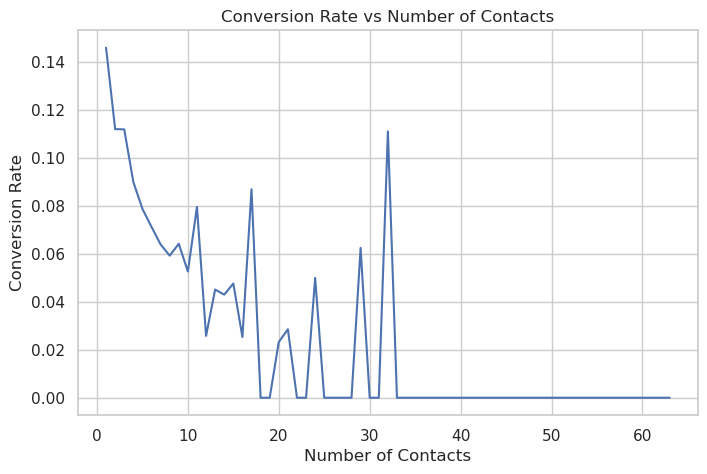

In [13]:
#conversion by number of campaign contacts
campaign_perf = df.groupby("campaign")["converted"].mean()

#plot
plt.figure(figsize = (8,5))
campaign_perf.plot()

plt.title("Conversion Rate vs Number of Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Conversion Rate")

plt.show()

### 11. CUSTOMER SEGMENTATION

In [14]:
#Conversion by job
job_conversion = df.groupby("job")["converted"].mean().sort_values(ascending = False)

job_conversion

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: converted, dtype: float64

### 12. CONVERSION VS CALL DURATION

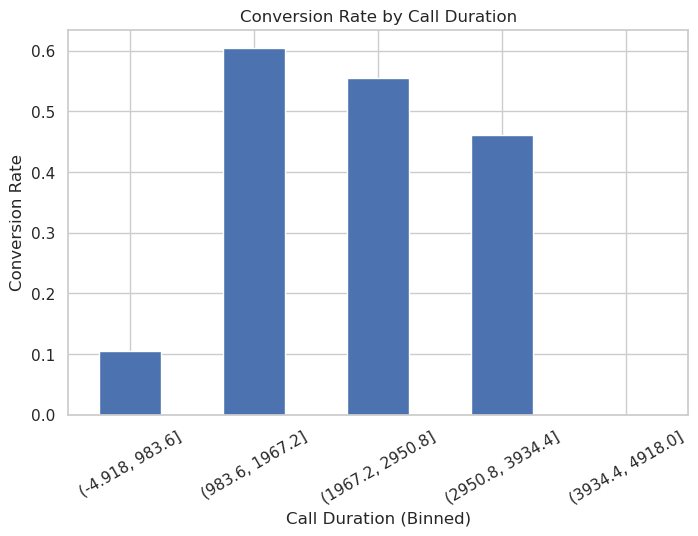

In [15]:
#creating duration bins
df["duration_bin"] = pd.cut(df["duration"], bins = 5)

#conversion by duration
duration_perf = df.groupby("duration_bin")["converted"].mean()

#plot
plt.figure(figsize = (8,5))
duration_perf.plot(kind = "bar")

plt.title("Conversion Rate by Call Duration")
plt.xlabel("Call Duration (Binned)")
plt.ylabel("Conversion Rate")

plt.xticks(rotation = 30)
plt.show()

### 13. EXPORTING THE CLEAN DATA

In [ ]:
#exporting cleaned dataset for dashboarding
df.to_csv("cleaned_bank_data.csv", index = False)